# Week 5 — Combining Models: CART, Boosting and Ensembles

**Practice tasks covered**
1. Implement CART (a decision tree) to categorise data: will it **rain tomorrow**?
2. Implement ensemble learning (bagging, random forest, boosting, voting, stacking) and compare them

Same task and same split as Week 2: train on 2012–2014, test on 2015, and the baseline is "tomorrow = today".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, VotingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import log_loss
from weather import load, split, FEATURES

train, test = split(load())
X_tr, y_tr = train[FEATURES].values, train.rain_tomorrow.values.astype(int)
X_te, y_te = test[FEATURES].values, test.rain_tomorrow.values.astype(int)
print("train days:", len(train), "| test days:", len(test))
print(f"'tomorrow = today' accuracy on 2015: {(test.rain.values == y_te).mean():.3f}")
print(f"with {len(test)} test days, one accuracy figure is uncertain by about ±{100 * np.sqrt(.7 * .3 / len(test)):.1f} points")

train days: 1096 | test days: 364
'tomorrow = today' accuracy on 2015: 0.703
with 364 test days, one accuracy figure is uncertain by about ±2.4 points


## Practice 1 — CART: a decision tree
A tree asks a series of yes/no questions about the inputs. At each step it picks the question that makes the two groups
**purest**, measured by the **Gini impurity** $1 - p_{rain}^2 - p_{dry}^2$ (0 = all one class).

### One split from scratch

In [2]:
def gini(y):
    p = y.mean()
    return 1 - p ** 2 - (1 - p) ** 2

def best_split(X, y):
    """Try every input and every threshold; keep the one with the lowest weighted impurity."""
    best = (np.inf, None, None)
    for j in range(X.shape[1]):
        for threshold in np.unique(X[:, j])[:-1]:
            left = X[:, j] <= threshold
            score = (left.sum() * gini(y[left]) + (~left).sum() * gini(y[~left])) / len(y)
            if score < best[0]: best = (score, j, threshold)
    return best

score, j, thr = best_split(X_tr, y_tr)
print(f"impurity before the split: {gini(y_tr):.3f}")
print(f"best first question: is {FEATURES[j]} <= {thr:.2f}?  (impurity after: {score:.3f})")

impurity before the split: 0.492
best first question: is precipitation <= 0.30?  (impurity after: 0.392)


### A full tree and what it learned

In [3]:
tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_tr, y_tr)
print(export_text(tree, feature_names=FEATURES))
print("same first question as the scratch code:", FEATURES[tree.tree_.feature[0]] == FEATURES[j])
print(f"accuracy on 2015: {tree.score(X_te, y_te):.3f}")

|--- precipitation <= 0.40
|   |--- temp_max <= 19.15
|   |   |--- temp_min <= 1.40
|   |   |   |--- class: 0
|   |   |--- temp_min >  1.40
|   |   |   |--- class: 0
|   |--- temp_max >  19.15
|   |   |--- temp_max <= 25.85
|   |   |   |--- class: 0
|   |   |--- temp_max >  25.85
|   |   |   |--- class: 0
|--- precipitation >  0.40
|   |--- month_cos <= -0.25
|   |   |--- precipitation <= 7.40
|   |   |   |--- class: 0
|   |   |--- precipitation >  7.40
|   |   |   |--- class: 1
|   |--- month_cos >  -0.25
|   |   |--- precipitation <= 9.00
|   |   |   |--- class: 1
|   |   |--- precipitation >  9.00
|   |   |   |--- class: 1

same first question as the scratch code: True
accuracy on 2015: 0.717


The tree reads like a flow chart. The first question is today's precipitation: if today was dry it says "no rain tomorrow"
whatever the temperature. If it rained, it says "rain" unless it was only a light shower in the colder half of the year.

### Over-fitting: how deep should the tree be?
We choose the depth on 2014 (fit on 2012–2013), not on the test year.

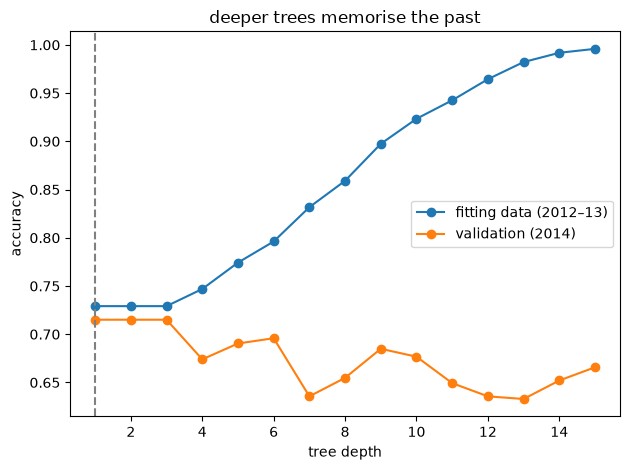

validation accuracy by depth: {1: 0.715, 2: 0.715, 3: 0.715, 4: 0.674, 5: 0.69, 6: 0.696, 7: 0.636, 8: 0.655, 9: 0.685, 10: 0.677, 11: 0.649, 12: 0.636, 13: 0.633, 14: 0.652, 15: 0.666}
best depth on validation: 1


In [4]:
fit_part, val_part = train[train.date < "2014-01-01"], train[train.date >= "2014-01-01"]
depths = range(1, 16)
fit_acc, val_acc = [], []
for depth in depths:
    t = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(fit_part[FEATURES], fit_part.rain_tomorrow)
    fit_acc.append(t.score(fit_part[FEATURES], fit_part.rain_tomorrow)); val_acc.append(t.score(val_part[FEATURES], val_part.rain_tomorrow))
best_depth = depths[int(np.argmax(val_acc))]
plt.plot(depths, fit_acc, "o-", label="fitting data (2012–13)"); plt.plot(depths, val_acc, "o-", label="validation (2014)")
plt.axvline(best_depth, color="grey", ls="--"); plt.xlabel("tree depth"); plt.ylabel("accuracy"); plt.legend(); plt.title("deeper trees memorise the past")
plt.tight_layout(); plt.show()
print("validation accuracy by depth:", dict(zip(depths, np.round(val_acc, 3).tolist())))
print("best depth on validation:", best_depth)

A deep tree gets nearly every training day right, but the validation accuracy does not follow: it memorises noise. For this
problem the best tree is the very simplest one (a single question, which is almost "tomorrow = today").
A deep tree is also **unstable**: change the training data slightly and its questions change. Averaging many trees steadies it.

## Practice 2 — Ensembles
### Bagging from scratch
Train many trees, each on a random re-sample of the training days, and let them **vote**.

In [5]:
rng = np.random.default_rng(0)
votes = np.zeros(len(X_te))
n_trees = 100
for _ in range(n_trees):
    pick = rng.integers(0, len(X_tr), len(X_tr))                  # bootstrap: sample days with replacement
    t = DecisionTreeClassifier(min_samples_leaf=10, random_state=0).fit(X_tr[pick], y_tr[pick])   # deep, unstable trees
    votes += t.predict(X_te)
bag_acc = ((votes / n_trees > .5) == y_te).mean()
one = DecisionTreeClassifier(min_samples_leaf=10, random_state=0).fit(X_tr, y_tr)
print(f"one deep tree: {one.score(X_te, y_te):.3f} | {n_trees} bagged deep trees: {bag_acc:.3f}")

one deep tree: 0.687 | 100 bagged deep trees: 0.706


### Comparing all the ensembles
Every model is compared the same way: 5-fold **time-series cross-validation** inside 2012–2014 (each fold tests on a later period
than it trains on), and then the 2015 test year.

In [6]:
models = {
    "logistic regression": LogisticRegression(max_iter=1000),
    "single deep tree": DecisionTreeClassifier(min_samples_leaf=10, random_state=0),
    "bagging": BaggingClassifier(DecisionTreeClassifier(min_samples_leaf=10), n_estimators=100, random_state=0),
    "random forest": RandomForestClassifier(300, min_samples_leaf=5, random_state=0),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, learning_rate=.5, random_state=0),
    "gradient boosting": GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=.05, random_state=0),
    "voting": VotingClassifier([("lr", LogisticRegression(max_iter=1000)), ("rf", RandomForestClassifier(300, min_samples_leaf=5, random_state=0)),
                                ("gb", GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=.05, random_state=0))], voting="soft"),
    "stacking": StackingClassifier([("rf", RandomForestClassifier(300, min_samples_leaf=5, random_state=0)),
                                    ("gb", GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=.05, random_state=0))],
                                   final_estimator=LogisticRegression(max_iter=1000), cv=5),
}
rows = {}
for name, model in models.items():
    cv = cross_val_score(model, X_tr, y_tr, cv=TimeSeriesSplit(5))
    model.fit(X_tr, y_tr)
    p = model.predict_proba(X_te)[:, 1]
    rows[name] = {"CV accuracy (2012–14)": cv.mean(), "test accuracy (2015)": ((p > .5) == y_te).mean(), "test log-loss": log_loss(y_te, p)}
results = pd.DataFrame(rows).T.round(3).sort_values("test accuracy (2015)", ascending=False)
results

,CV accuracy (2012–14),test accuracy (2015),test log-loss
logistic regression,0.712,0.728,0.559
voting,0.700,0.725,0.541
random forest,0.690,0.717,0.547
AdaBoost,0.703,0.709,0.574
gradient boosting,0.655,0.709,0.548
stacking,0.636,0.709,0.552
bagging,0.686,0.706,0.550
single deep tree,0.658,0.687,2.816


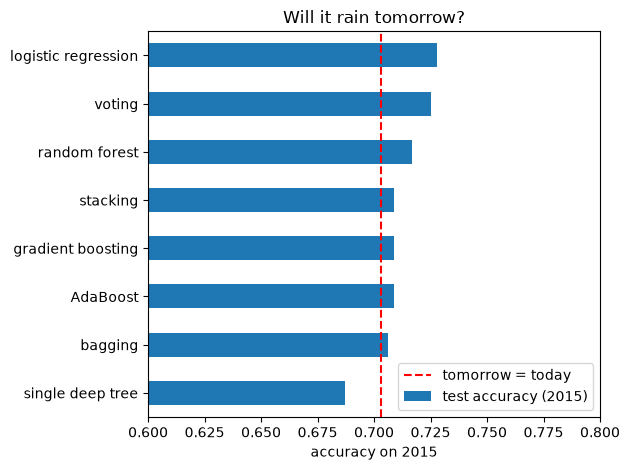

In [7]:
ax = results["test accuracy (2015)"].sort_values().plot.barh(color="tab:blue")
ax.axvline((test.rain.values == y_te).mean(), color="r", ls="--", label="tomorrow = today")
ax.set_xlim(.6, .8); ax.set_xlabel("accuracy on 2015"); ax.legend(); ax.set_title("Will it rain tomorrow?")
plt.tight_layout(); plt.show()

### What does the forest rely on?

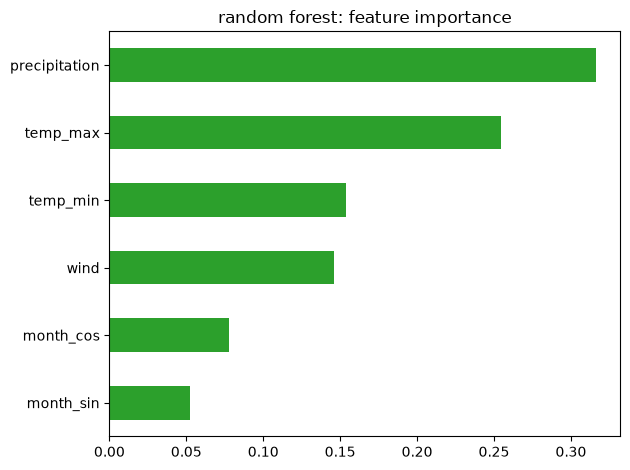

In [8]:
forest = models["random forest"]
imp = pd.Series(forest.feature_importances_, index=FEATURES).sort_values()
imp.plot.barh(color="tab:green"); plt.title("random forest: feature importance"); plt.tight_layout(); plt.show()

## Summary
* A deep tree is easy to read but memorises noise (68.7% on 2015, and a log-loss of 2.8 because it is wildly over-confident).
  Averaging many of them (bagging 70.6%, random forest 71.7%) steadies it and cuts the log-loss to about 0.55.
* Boosting, voting and stacking land at 70.9–72.5%. **Plain logistic regression (72.8%) is as accurate as any of them**; voting has the
  best log-loss (0.541) by a small margin. With only 364 test days (±2.4 points), none of these differences is convincing.
* Why? Whether it rains tomorrow depends on today's weather in a fairly simple, additive way, so there is little for flexible
  models to find. More complex is not automatically better: always compare against a simple baseline.